In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def load_current(filename):
    X = pd.read_csv(filename)
    X["datetime"] = pd.to_datetime(X["datetime"])
    X.set_index("datetime", inplace=True)
    return X

def load_forecast(filename):
    X = pd.read_csv(filename)
    X["datetime"] = pd.to_datetime(X["datetime"])
    X["forecast_datetime"] = pd.to_datetime(X["forecast_datetime"])
    return X

In [3]:
C = load_current("current_temp.csv.gz")
F = load_forecast("forecast_temp.csv.gz")

In [4]:
C

,temp
datetime,
2025-10-11 14:12:17,4.81
2025-10-11 14:14:16,4.81
2025-10-11 14:16:16,4.81
2025-10-11 14:17:16,4.81
2025-10-11 14:19:16,4.77
...,...
2026-01-20 16:16:43,-16.38
2026-01-20 16:26:43,-16.42
2026-01-20 16:36:44,-16.40


In [5]:
F

,datetime,forecast_datetime,temp
0,2025-10-11 14:12:17,2025-10-11 14:00:00,4.81
1,2025-10-11 14:12:17,2025-10-11 15:00:00,4.76
2,2025-10-11 14:12:17,2025-10-11 16:00:00,4.43
3,2025-10-11 14:12:17,2025-10-11 17:00:00,3.82
4,2025-10-11 14:12:17,2025-10-11 18:00:00,3.17
...,...,...,...
667435,2026-01-20 17:11:40,2026-01-22 12:00:00,-2.36
667436,2026-01-20 17:11:40,2026-01-22 13:00:00,-3.45
667437,2026-01-20 17:11:40,2026-01-22 14:00:00,-5.79
667438,2026-01-20 17:11:40,2026-01-22 15:00:00,-4.98


In [6]:
Ca = C["temp"].resample("1d", origin="start_day").agg(["mean", "min", "max"])
Ca

,mean,min,max
datetime,,,
2025-10-11,4.532821,4.39,4.81
2025-10-12,4.635532,3.05,8.03
2025-10-13,1.721458,-1.65,3.32
2025-10-14,2.650833,-1.81,7.96
2025-10-15,2.069583,-1.61,5.66
...,...,...,...
2026-01-16,-9.571469,-14.74,-4.69
2026-01-17,-12.845319,-16.55,-7.37
2026-01-18,-13.836111,-16.29,-10.43


(array([20376., 20393., 20407., 20423., 20437., 20454., 20468.]),
 [Text(20376.0, 0, '2025-10-15'),
  Text(20393.0, 0, '2025-11-01'),
  Text(20407.0, 0, '2025-11-15'),
  Text(20423.0, 0, '2025-12-01'),
  Text(20437.0, 0, '2025-12-15'),
  Text(20454.0, 0, '2026-01-01'),
  Text(20468.0, 0, '2026-01-15')])

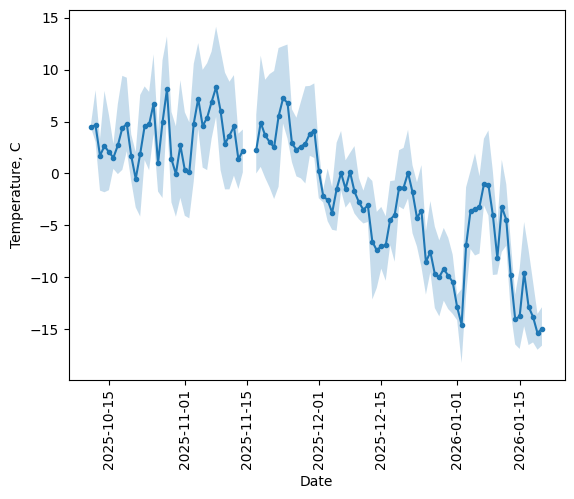

In [7]:
plt.plot(Ca["mean"], '.-')
plt.fill_between(x=Ca.index,
                 y1=Ca["max"],
                 y2=Ca["min"],
                 alpha=0.25)
plt.xlabel("Date")
plt.ylabel("Temperature, C")
plt.xticks(rotation=90)

In [8]:
F["time_delta"] = F["forecast_datetime"] - F["datetime"]

In [9]:
F.drop(columns=["datetime"], inplace=True)

In [10]:
F.set_index("forecast_datetime", inplace=True)

In [11]:
F.index.is_monotonic_increasing, C.index.is_monotonic_increasing

(False, True)

In [12]:
F.sort_index(inplace=True)
F.index.is_monotonic_increasing, C.index.is_monotonic_increasing

(True, True)

```python
%timeit pd.merge_asof(F, C, left_index=True, right_index=True, suffixes=("_forecast","_current"), direction="nearest", tolerance=pd.Timedelta("5min"))
```

```
57 ms ± 3.06 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
```

```python
F = F.reset_index()
C = C.reset_index()
%timeit pd.merge_asof(F, C, left_on="forecast_datetime", right_on="datetime", suffixes=("_forecast","_current"), direction="nearest", tolerance=pd.Timedelta("5min"))
```

```
90.1 ms ± 4.88 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
```

In [13]:
M = pd.merge_asof(F, C,
              left_index=True, right_index=True,
              suffixes=("_forecast","_current"),
              direction="nearest",
              tolerance=pd.Timedelta("5min"))
M.dropna(axis=0, inplace=True)
M["temp_delta"] = M["temp_forecast"] - M["temp_current"]
M.drop(columns=["temp_forecast", "temp_current"], inplace=True)

In [14]:
M = M.set_index("time_delta").sort_index()
M

,temp_delta
time_delta,
-1 days +23:02:34,-0.08
-1 days +23:02:53,-0.39
-1 days +23:02:58,-0.10
-1 days +23:02:58,0.13
-1 days +23:03:01,-0.07
...,...
1 days 22:54:43,1.90
1 days 22:55:44,1.90
1 days 22:56:44,1.90


Text(0, 0.5, 'Temperature, C')

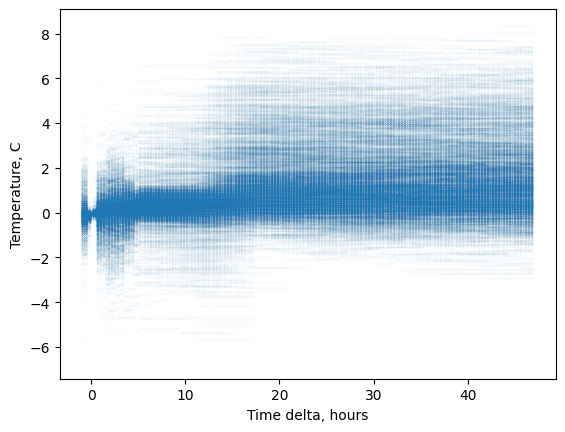

In [15]:
plt.scatter(M.index / pd.Timedelta("1h"),
            M["temp_delta"],
            s=0.0125, alpha=0.125)
plt.xlabel("Time delta, hours")
plt.ylabel("Temperature, C")

In [16]:
Ma = M.groupby(M.index.floor("1h")).agg(["mean", "std"])
Ma.index += 0.5 * pd.Timedelta("1h")
Ma

temp_delta          
                        mean       std
time_delta                            
-1 days +23:30:00  -0.064780  0.599202
0 days 00:30:00    -0.037718  0.558414
0 days 01:30:00     0.005433  0.938459
0 days 02:30:00     0.067359  1.043562
0 days 03:30:00     0.135040  0.949437
0 days 04:30:00     0.195239  0.819432
0 days 05:30:00     0.351154  0.849384
0 days 06:30:00     0.364029  0.900295
0 days 07:30:00     0.373438  0.946545
0 days 08:30:00     0.385189  0.984646
0 days 09:30:00     0.400380  1.036952
0 days 10:30:00     0.423088  1.096289
0 days 11:30:00     0.443253  1.207167
0 days 12:30:00     0.572660  1.359392
0 days 13:30:00     0.745958  1.480229
0 days 14:30:00     0.923872  1.563478
0 days 15:30:00     1.096594  1.618982
0 days 16:30:00     1.270970  1.657274
0 days 17:30:00     1.436589  1.631281
0 days 18:30:00     1.475465  1.622464
0 days 19:30:00     1.472057  1.625092
0 days 20:30:00     1.469312  1.627553
0 days 21:30:00     1.466202  1.624300
0 days 22:30:00     1.460699  1.624274
0 days 23:30:00     1.459644  1.627657
1 days 00:30:00     1.457945  1.639047
1 days 01:30:00     1.458176  1.643483
1 days 02:30:00     1.460610  1.646593
1 days 03:30:00     1.461152  1.652592
1 days 04:30:00     1.468208  1.653760
1 days 05:30:00     1.472568  1.656527
1 days 06:30:00     1.481813  1.656367
1 days 07:30:00     1.486794  1.658106
1 days 08:30:00     1.489354  1.668151
1 days 09:30:00     1.493599  1.672463
1 days 10:30:00     1.493046  1.675399
1 days 11:30:00     1.496009  1.676163
1 days 12:30:00     1.500182  1.681221
1 days 13:30:00     1.509022  1.688006
1 days 14:30:00     1.519693  1.693854
1 days 15:30:00     1.529551  1.700651
1 days 16:30:00     1.541037  1.705046
1 days 17:30:00     1.547548  1.714873
1 days 18:30:00     1.548182  1.721850
1 days 19:30:00     1.552821  1.732059
1 days 20:30:00     1.560693  1.740387
1 days 21:30:00     1.567819  1.750234
1 days 22:30:00     1.573913  1.756395

Text(0.5, 0, 'Delta time, hours')

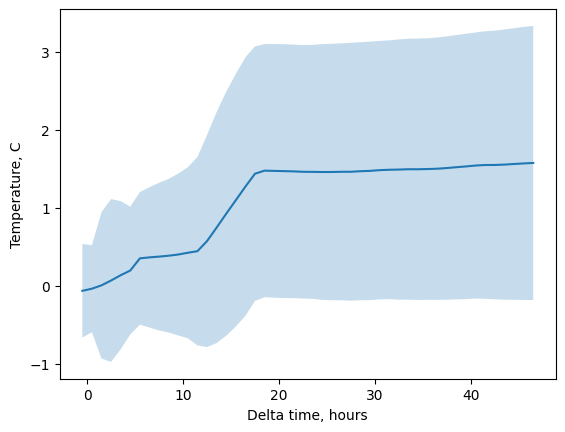

In [17]:
plt.plot(Ma.index / pd.Timedelta("1h"),
         Ma["temp_delta"]["mean"])
plt.fill_between(x=Ma.index / pd.Timedelta("1h"),
                 y1=Ma["temp_delta"]["mean"] + Ma["temp_delta"]["std"],
                 y2=Ma["temp_delta"]["mean"] - Ma["temp_delta"]["std"],
                 alpha=0.25)
plt.ylabel("Temperature, C")
plt.xlabel("Delta time, hours")